In [15]:
import cutlass 
import torch 
import cutlass.cute as cute 
from cutlass.cute.runtime import from_dlpack
import cute_viz

In [25]:
@cute.kernel 
def tiled_mma_kern(gA:cute.Tensor, gB:cute.Tensor,gC:cute.Tensor, tiled_mma: cute.TiledMma):
  t,_,_ = cute.arch.thread_idx()
  thread_mma = tiled_mma.get_slice(t)
  thread_slice_A = thread_mma.partition_A(gA)
  thread_slice_B = thread_mma.partition_B(gB)
  thread_slice_C = thread_mma.partition_C(gC)
  print(thread_slice_A.layout) 
  print(thread_slice_B.layout)
  print(thread_slice_C.layout)
  tCrA = tiled_mma.make_fragment_A(thread_slice_A)
  print(tCrA.shape)
  tCrB = tiled_mma.make_fragment_B(thread_slice_B)
  tCrC = tiled_mma.make_fragment_C(thread_slice_C)
  tCrC.fill(0.0)
  cute.autovec_copy(thread_slice_A, tCrA)
  cute.autovec_copy(thread_slice_B, tCrB)
  #for k in range(tCrA.shape[2]):
  cute.gemm(tiled_mma, tCrC, tCrA[None,None,None], tCrB[None,None,None], tCrC)
  cute.autovec_copy(tCrC, thread_slice_C)

In [26]:
@cute.jit 
def tiled_mma_launcher(gA:cute.Tensor, gB:cute.Tensor, gC:cute.Tensor): 
  op = cute.nvgpu.warp.MmaF16BF16Op(
    cutlass.BFloat16,          # fp16
    cutlass.Float32,        # fp32
    (16, 8, 16)      # mma_inst_mnk
  ) 
  permutation_mnk = (32,8,32)
  atom_layout = (1,1,1)
  tC = cute.make_layout(atom_layout)
  tiled_mma = cute.make_tiled_mma(op, tC, permutation_mnk=permutation_mnk)
  cute_viz.display_tiled_mma(tiled_mma,(32,8,32))
  cute_viz.display_tv_layout(tiled_mma.tv_layout_A,(16,16))
  tiled_mma_kern(gA,gB,gC,tiled_mma).launch(grid = [1,1,1], block =[32,1,1])
  print(tiled_mma)
    

tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0

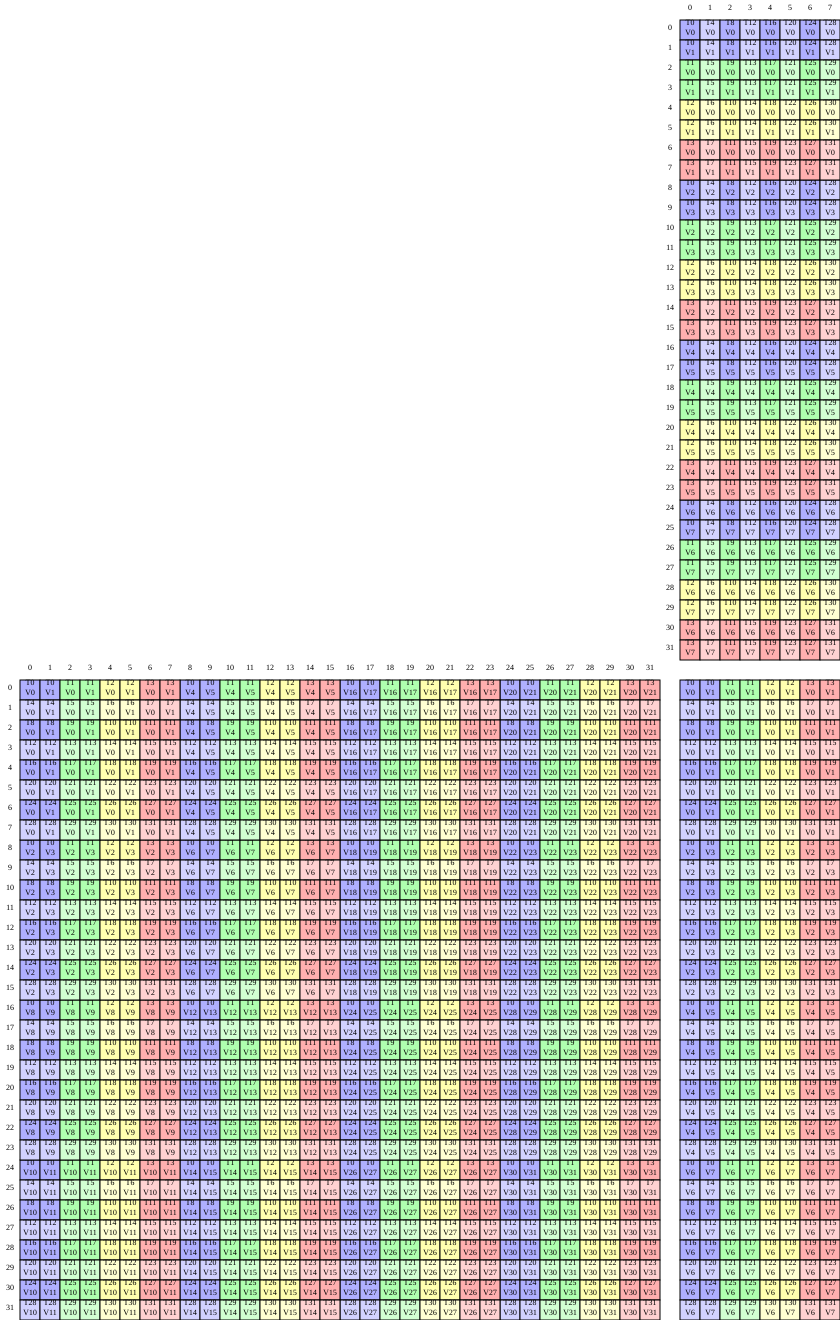

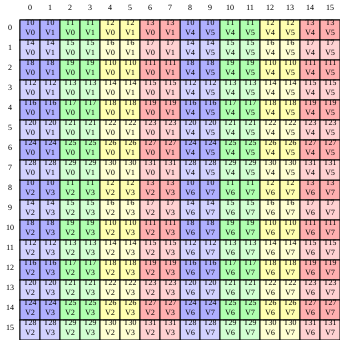

((2,2,2),2,2):((1,256,8),512,16)
((2,2),1,2):((1,8),0,16)
((2,2),2,1):((1,64),128,0)
((2, 2, 2), 2, 2)
Tiled MMA
  Thr Layout VMNK: (32,1,1,1):(1,0,0,0)
  Permutation MNK: (32:1,8:1,32:1)
MMA Atom
  ThrID:           32:1
  Shape MNK:       (16,8,16)
  TV Layout A:     ((4,8),(2,2,2)):((32,1),(16,8,128))
  TV Layout B:     ((4,8),(2,2)):((16,1),(8,64))
  TV Layout C:     ((4,8),(2,2)):((32,1),(16,8))
tensor([[  2.9415,   2.2785,  -6.6268,  10.8077,   5.0932,  -1.7366,   1.1877,
           2.2772],
        [  8.5167,   0.2200,  -6.5578,  -0.6294,   5.6078,  10.2780,  -9.2793,
           3.5296],
        [  5.6999,  -4.5921,  -2.4341,   4.4344,  -1.9788,   4.9804,   4.4965,
           7.5254],
        [ 16.0576,   6.2609,   1.3226,   4.7334,  -4.9515,  -5.9580,  -2.0546,
           8.7272],
        [ -4.2505,  -0.6814,   0.5529,  -2.0680,   1.7331,  -5.2319,  -0.6064,
           2.8472],
        [ -5.5322,  -0.1185,  -4.7276,  -5.5389,   1.1107,  -0.1032,   5.3052,
          -4.6803],
   

In [27]:
M = 32
N = 8
K = 32

a = torch.randn(M, K, device="cuda", dtype=torch.bfloat16)
b = torch.randn(N, K, device="cuda", dtype=torch.bfloat16)
c = torch.zeros(M, N, device="cuda", dtype=torch.float32)
print(c)
a_ = from_dlpack(a, assumed_align=16)
b_ = from_dlpack(b, assumed_align=16)
c_ = from_dlpack(c, assumed_align=16)

tiled_mma_kern_ = cute.compile(tiled_mma_launcher, a_, b_, c_)
tiled_mma_kern_(a_, b_, c_)
print(c)
print(torch.matmul(a.float(),b.transpose(0,1).float()))
print(torch.testing.assert_close(c, torch.matmul(a.float(),b.transpose(0,1).float())))